# Perceptrón desde cero
**Implementación sin librerías de ML — solo NumPy y Matplotlib**

## 1. Imports y generación del dataset

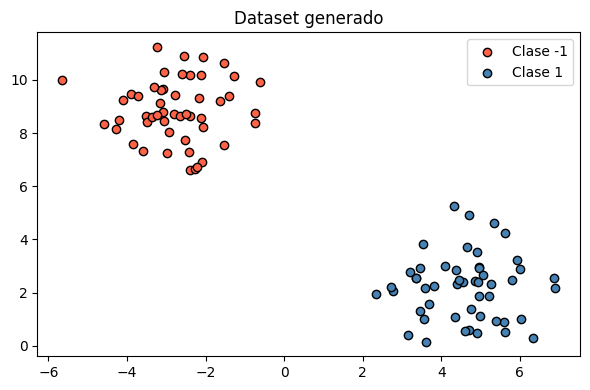

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Dataset linealmente separable
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)
y = np.where(y == 0, -1, 1)  # clases: -1 y 1

plt.figure(figsize=(6, 4))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='tomato', label='Clase -1', edgecolors='k')
plt.scatter(X[y ==  1, 0], X[y ==  1, 1], color='steelblue', label='Clase 1', edgecolors='k')
plt.title('Dataset generado')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Clase Perceptrón

In [2]:
class Perceptron:
    def __init__(self, n_features, lr=0.1, n_epochs=100):
        """Inicializa pesos aleatorios pequeños y bias en 0."""
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        self.lr = lr
        self.n_epochs = n_epochs
        self.errors_per_epoch = []

    def activation(self, z):
        """Función escalón: devuelve 1 si z >= 0, else -1."""
        return np.where(z >= 0, 1, -1)

    def predict(self, X):
        """Forward pass: X @ w + b → activación."""
        z = X @ self.weights + self.bias
        return self.activation(z)

    def train(self, X, y):
        """Regla del perceptrón: w += lr * (y - y_hat) * x"""
        self.weights_history = [self.weights.copy()]
        self.bias_history = [self.bias]

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self.predict(xi.reshape(1, -1))[0]
                update = self.lr * (yi - y_hat)
                self.weights += update * xi
                self.bias   += update
                if y_hat != yi:
                    errors += 1
            self.errors_per_epoch.append(errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            if errors == 0:
                print(f'Convergió en época {epoch + 1}')
                break
        else:
            print(f'No convergió en {self.n_epochs} épocas')

## 3. Entrenamiento y gráficos

Convergió en época 2


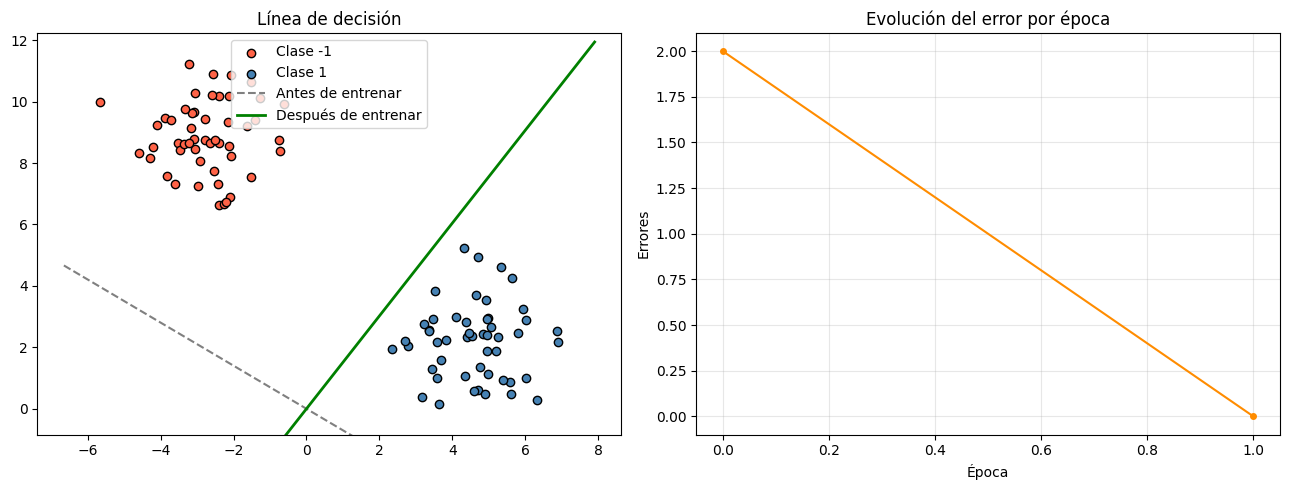

In [3]:
def decision_line(weights, bias, x_range):
    """Devuelve y para la línea: w0*x + w1*y + b = 0  →  y = (-w0*x - b) / w1"""
    return (-weights[0] * x_range - bias) / weights[1]

p = Perceptron(n_features=2, lr=0.1, n_epochs=100)

w_antes = p.weights.copy()
b_antes = p.bias

p.train(X, y)

x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico 1: Puntos + líneas de decisión ---
ax = axes[0]
ax.scatter(X[y == -1, 0], X[y == -1, 1], color='tomato', label='Clase -1', edgecolors='k', zorder=3)
ax.scatter(X[y ==  1, 0], X[y ==  1, 1], color='steelblue', label='Clase 1', edgecolors='k', zorder=3)

if abs(w_antes[1]) > 1e-9:
    y_antes = decision_line(w_antes, b_antes, x_range)
    ax.plot(x_range, y_antes, 'gray', linestyle='--', label='Antes de entrenar')

y_despues = decision_line(p.weights, p.bias, x_range)
ax.plot(x_range, y_despues, 'green', linewidth=2, label='Después de entrenar')

ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.set_title('Línea de decisión')
ax.legend()

# --- Gráfico 2: Error por época ---
ax2 = axes[1]
ax2.plot(p.errors_per_epoch, color='darkorange', marker='o', markersize=4)
ax2.set_xlabel('Época')
ax2.set_ylabel('Errores')
ax2.set_title('Evolución del error por época')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Experimento: datos NO linealmente separables

No convergió en 50 épocas


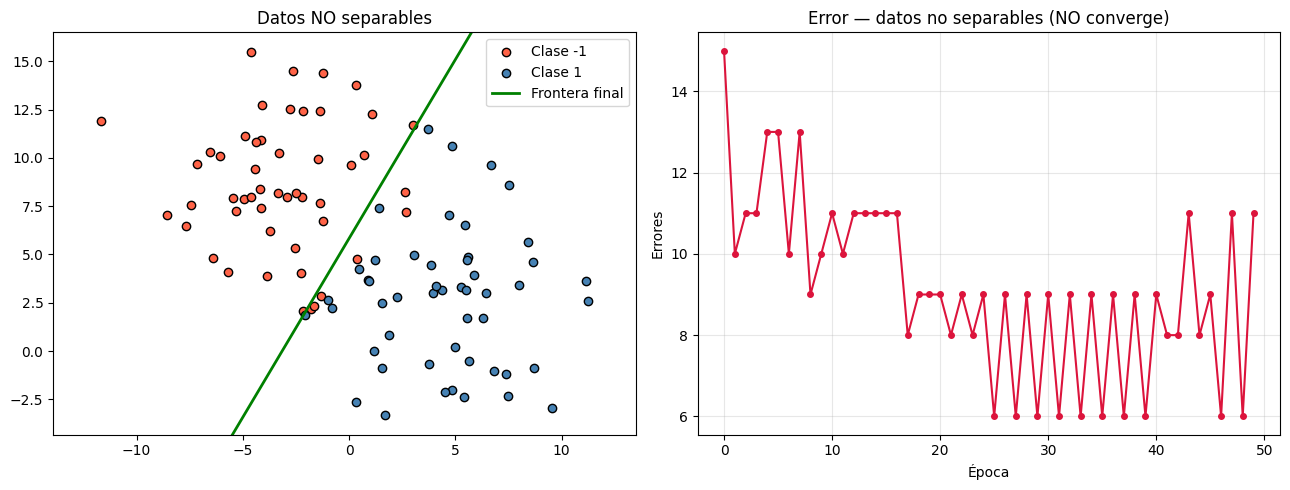

Observación: el error nunca llega a 0 porque los datos se solapan.
El perceptrón clásico NO garantiza convergencia si los datos no son linealmente separables.


In [4]:
X_ns, y_ns = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=3.5)
y_ns = np.where(y_ns == 0, -1, 1)

p_ns = Perceptron(n_features=2, lr=0.1, n_epochs=50)
p_ns.train(X_ns, y_ns)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(X_ns[y_ns == -1, 0], X_ns[y_ns == -1, 1], color='tomato', edgecolors='k', label='Clase -1')
ax.scatter(X_ns[y_ns ==  1, 0], X_ns[y_ns ==  1, 1], color='steelblue', edgecolors='k', label='Clase 1')
x_r = np.linspace(X_ns[:, 0].min()-1, X_ns[:, 0].max()+1, 200)
ax.plot(x_r, decision_line(p_ns.weights, p_ns.bias, x_r), 'green', linewidth=2, label='Frontera final')
ax.set_ylim(X_ns[:, 1].min()-1, X_ns[:, 1].max()+1)
ax.set_title('Datos NO separables')
ax.legend()

ax2 = axes[1]
ax2.plot(p_ns.errors_per_epoch, color='crimson', marker='o', markersize=4)
ax2.set_xlabel('Época')
ax2.set_ylabel('Errores')
ax2.set_title('Error — datos no separables (NO converge)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Observación: el error nunca llega a 0 porque los datos se solapan.')
print('El perceptrón clásico NO garantiza convergencia si los datos no son linealmente separables.')

## 5. Preguntas

###  ¿Por qué el perceptrón no puede resolver XOR?

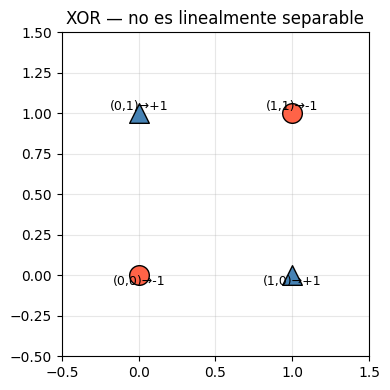

In [5]:
# Visualización del XOR
xor_X = np.array([[0,0],[0,1],[1,0],[1,1]])
xor_y = np.array([-1, 1, 1, -1])  # XOR

plt.figure(figsize=(4, 4))
for xi, yi in zip(xor_X, xor_y):
    color = 'steelblue' if yi == 1 else 'tomato'
    marker = '^' if yi == 1 else 'o'
    plt.scatter(*xi, color=color, s=200, marker=marker, edgecolors='k', zorder=3)

plt.text(0, 0, '(0,0)→-1', fontsize=9, ha='center', va='top')
plt.text(0, 1, '(0,1)→+1', fontsize=9, ha='center', va='bottom')
plt.text(1, 0, '(1,0)→+1', fontsize=9, ha='center', va='top')
plt.text(1, 1, '(1,1)→-1', fontsize=9, ha='center', va='bottom')
plt.title('XOR — no es linealmente separable')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Respuesta:** El perceptrón aprende un hiperplano (en 2D: una recta) que divide el espacio en dos regiones. XOR produce una distribución donde los puntos de cada clase están en esquinas opuestas del cuadrado — no existe ninguna recta capaz de separar `{(0,0),(1,1)}` de `{(0,1),(1,0)}`. Para resolver XOR se necesita al menos una capa oculta (red neuronal multicapa), que genera representaciones no lineales del espacio.

###  ¿Qué pasa si se cambia el learning rate? — 3 valores

Convergió en época 2
Convergió en época 2
Convergió en época 1


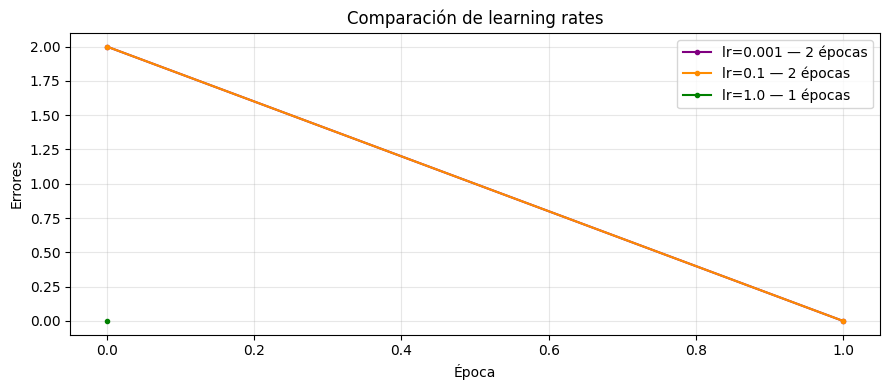

In [6]:
learning_rates = [0.001, 0.1, 1.0]
colors = ['purple', 'darkorange', 'green']

plt.figure(figsize=(9, 4))
for lr, col in zip(learning_rates, colors):
    p_lr = Perceptron(n_features=2, lr=lr, n_epochs=100)
    p_lr.train(X, y)
    plt.plot(p_lr.errors_per_epoch, color=col, marker='o', markersize=3,
             label=f'lr={lr} — {len(p_lr.errors_per_epoch)} épocas')

plt.xlabel('Época')
plt.ylabel('Errores')
plt.title('Comparación de learning rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**lr=0.001 (muy bajo):** Convergió en 2 épocas. Con datos tan separables no se nota diferencia respecto a lr más altos, pero en datasets con menor margen entre clases necesitaría muchas más épocas porque cada actualización de pesos es mínima.

**lr=0.1 (moderado):** Convergió en 2 épocas. Balance estándar entre velocidad y estabilidad.

**lr=1.0 (alto):** Convergió en 1 época. Al ser el paso más grande, encontró la frontera antes. En datos con solapamiento podría oscilar sin converger.

**Conclusión:** En este dataset los tres lr convergieron en 1-2 épocas porque la separación entre clases es muy grande. Para ver diferencias reales habría que usar datos con margen más pequeño. Esto confirma el Teorema de Convergencia del Perceptrón: si los datos son linealmente separables, siempre converge independientemente del lr — este solo afecta la velocidad cuando la separación es ajustada.

###  ¿Cuántas épocas necesitó para converger? ¿De qué depende?

In [7]:
epocas = len(p.errors_per_epoch)
print(f'El perceptrón principal convergió en {epocas} época(s).')

El perceptrón principal convergió en 2 época(s).


**Respuesta:** La cantidad de épocas necesarias para converger depende de:
1. **Separabilidad de los datos:** cuanto más "fácil" es la separación (gran margen entre clases), menos épocas.
2. **Learning rate:** valores más altos aceleran la convergencia en datos separables.
3. **Inicialización de pesos:** si los pesos iniciales ya apuntan hacia la solución, converge antes.
4. **Cantidad de muestras y dimensionalidad:** más datos implican más actualizaciones por época.

El **Teorema de Convergencia del Perceptrón** garantiza que, si los datos son linealmente separables, el algoritmo *siempre* converge en un número finito de pasos.